In [1]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd

color_palette = {}
color_palette['wt'] = 'blue'
color_palette['mutated'] = 'red'
color_palette['heterozygous'] = 'orange'

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir


In [2]:
lib = '1'
BC = 'BC002'

adata_dir = large_data_dir + 'MPN_WTA/MPN_' + lib + '_' + BC + '_genotyped.h5ad'
adata = sc.read_h5ad(adata_dir)
gf_utils.assign_genotypes(adata, min_counts=1, min_p=0.6)

SRSF2 c.161C>T 11989
JAK2 c.1849G>T 6015
SH2B3 c.894G>A 7648
ASXL1 c.1249C>T 2457


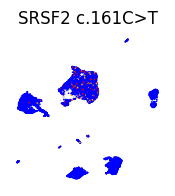

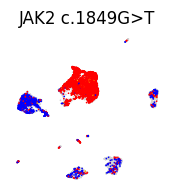

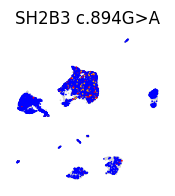

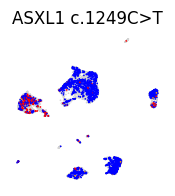

In [3]:
for variant in adata.obsm['genotype_call'].columns[0:4]:
    adata.obs[variant + '_call'] = adata.obsm['genotype_call'][variant] 
    print(variant, adata.obs[variant + '_call'].notna().sum()) ## check number of cells genotyped
    
    fig,ax = plt.subplots(figsize=(2,2))
    sc.pl.umap(adata, color = variant + '_call', palette=color_palette, frameon=False, ax=ax, show=False, legend_loc=None,title = variant[0:15])
    
    plt.savefig('../plots/' + lib + '_' + BC + '_' + variant + '_UMAP.pdf')


In [4]:
palette = dict(zip(adata.obs['cell_type'].cat.categories, adata.uns['cell_type_colors']))
adata.obs['cell_type'] = adata.obs['cell_type'].replace({'Classical monocyte 2 (non-HSPC)':'Classical monocyte (non-HSPC)'})

/tmp/ipykernel_753499/1914003319.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['cell_type'] = adata.obs['cell_type'].replace({'Classical monocyte 2 (non-HSPC)':'Classical monocyte (non-HSPC)'})


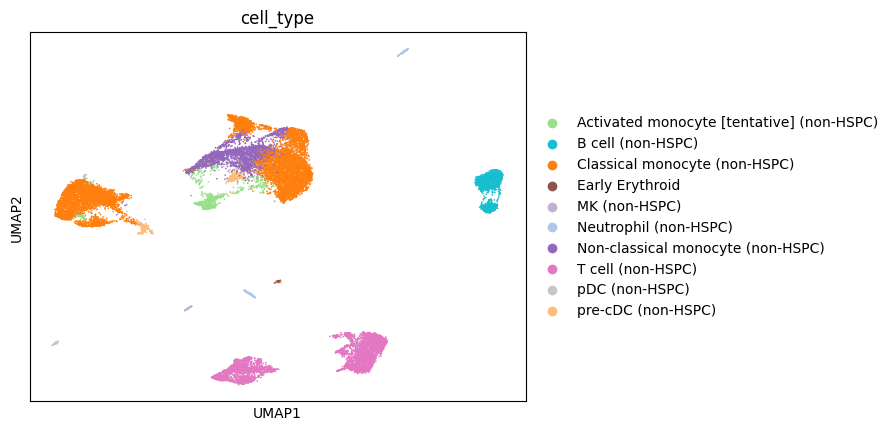

In [5]:
fig,ax = plt.subplots()

sc.pl.umap(adata, color = 'cell_type', ax=ax, show=False, palette=palette)

plt.savefig('../plots/' + lib + '_' + BC + '_cell_type_umap.pdf', bbox_inches='tight')